# Policy sweep results

Loads a run of `experiments/run_policy_sweep.py` and inspects it: which
policy wins each configuration, by how much, and whether the difference is
statistically real.

Nothing here re-runs anything -- it only reads `experiments/results/<run_name>/`.
See `experiments/README.md` for the column conventions.

**What a policy sweep measures.** For each configuration, every policy is run
over `n_reps` replications sharing one seed sequence (common random numbers),
so the policies face *identical* arrival streams. Differences are then paired
per seed, which removes most of the between-replication noise and is what
makes a modest difference detectable at 30 replications.

In [1]:
%load_ext autoreload
%autoreload 2

import json

import pandas as pd
import matplotlib.pyplot as plt

from experiments.core import DEFAULT_OUT_DIR, list_runs, load_meta
from experiments.policy_sweep import load_results, metric_table, metric_slug
from visualization.style import new_figure, style_axes, style_legend, palette

## Point this at a run

`RUN_NAME` is what you passed to `run_policy_sweep` (the `RUN_NAME` constant
in `experiments/run_policy_sweep.py`, `"policy_sweep"` by default).

In [2]:
print("runs on disk:", list_runs())

RUN_NAME = "queue_sweep_LSoCD_1pile"   # <-- edit me

results = load_results(RUN_NAME)                    # one row per (config, policy)
comparisons = load_results(RUN_NAME, "comparisons")  # one row per (config, pair, metric)
wide = load_results(RUN_NAME, "results_wide")        # one row per config
reps = load_results(RUN_NAME, "replications")        # raw per-replication values

meta = load_meta(RUN_NAME)
print(f"{meta['n_configs']} config(s), {len(results)} policy run(s), "
      f"{len(reps)} episodes, {meta.get('total_runtime_s', float('nan')):.1f}s")
results.head()

runs on disk: ['queue_sweep_LSoCD_3pile', 'queue_sweep_LSoCD_2pile', 'queue_sweep_LSoCD_1pile', '1pile_75kwh', 'queue_sweep_PMatch', 'power_sweep', 'queue_sweep_LSoCD', 'test']
11 config(s), 22 policy run(s), 660 episodes, 61.5s


,config_id,n_piles,n_connectors,n_modules,p_module,queue_capacity,mean_interarrival,max_time,warmup_period,flush_queue_at_warmup,...,avg_charge_time_all_ci_high,avg_charge_time_all_measured_mean,avg_charge_time_all_measured_ci_low,avg_charge_time_all_measured_ci_high,avg_sys_time_all_mean,avg_sys_time_all_ci_low,avg_sys_time_all_ci_high,avg_sys_time_all_measured_mean,avg_sys_time_all_measured_ci_low,avg_sys_time_all_measured_ci_high
0,0,1,2,6,25.0,1000,60.0,1440,360,False,...,28.664924,27.725501,27.133478,28.317524,29.077636,28.302534,29.852738,28.542323,27.861815,29.222832
1,0,1,2,6,25.0,1000,60.0,1440,360,False,...,28.664925,27.726057,27.134269,28.317846,29.069419,28.293800,29.845037,28.533706,27.851854,29.215559
2,1,1,2,6,25.0,1000,40.0,1440,360,False,...,29.991974,29.294781,28.821593,29.767969,32.577154,31.609205,33.545103,32.105648,31.176713,33.034584
3,1,1,2,6,25.0,1000,40.0,1440,360,False,...,30.009813,29.305557,28.829983,29.781131,32.540775,31.581015,33.500534,32.082162,31.163454,33.000869
4,2,1,2,6,25.0,1000,30.0,1440,360,False,...,31.143628,30.556808,30.099612,31.014005,37.536642,35.834037,39.239246,36.789064,35.060177,38.517951


## Pick the swept axis and the metric

`SWEPT` should be whatever you actually varied (the first key of `SWEEP` in
the runner script). `METRIC` is a human-readable name from
`DEFAULT_METRICS`; the full list is printed below.

`MEASURED=True` selects the post-warm-up counterpart of the metric, which is
identical to the whole-run one unless the scenario set a `warmup_period`.

In [3]:
# Every metric recorded, as the human-readable names metric_table expects.
metrics = sorted({c[:-5] for c in results.columns if c.endswith("_mean")})
print("metric column slugs:", metrics)

SWEPT = "mean_interarrival"   # the knob you varied
METRIC = "avg sys time (all)"       # mean sojourn W = W_q + S
MEASURED = True              # True -> the post-warm-up counterpart

metric column slugs: ['average_l', 'average_l_measured', 'average_q', 'average_q_measured', 'avg_charge_time', 'avg_charge_time_all', 'avg_charge_time_all_measured', 'avg_charge_time_measured', 'avg_sys_time', 'avg_sys_time_all', 'avg_sys_time_all_measured', 'avg_sys_time_measured', 'avg_wait_time', 'avg_wait_time_all', 'avg_wait_time_all_measured', 'avg_wait_time_measured', 'dropped_evs', 'dropped_evs_measured', 'finished_evs', 'finished_evs_measured', 'in_system_evs', 'in_system_evs_measured', 'max_wait_time', 'max_wait_time_all', 'max_wait_time_all_measured', 'max_wait_time_measured', 'total_energy_delivered_kwh', 'total_energy_delivered_kwh_measured', 'util_rho_sim', 'util_rho_sim_measured', 'util_rho_theory', 'util_rho_theory_measured']


## Headline: the metric by policy

Rows are configurations, columns are policies. Lower is better for the time
metrics.

In [4]:
metric_table(results, METRIC, measured=MEASURED, index=SWEPT).round(3)

policy,FIFO,LSoCD
mean_interarrival,,
60.000000,28.542,28.534
40.000000,32.106,32.082
30.000000,36.789,36.601
24.000000,44.037,43.603
20.000000,61.975,60.560
17.142857,106.713,103.935
15.000000,183.897,177.082
13.333333,271.701,260.907
12.000000,337.710,320.988


## Plot: metric vs. the swept knob, with confidence bands

One line per policy, shaded to its confidence interval. Where the bands
overlap heavily, the per-policy CIs are not evidence of a difference -- read
the paired test in the next section instead, which is far more sensitive
because it removes the shared arrival-stream noise.

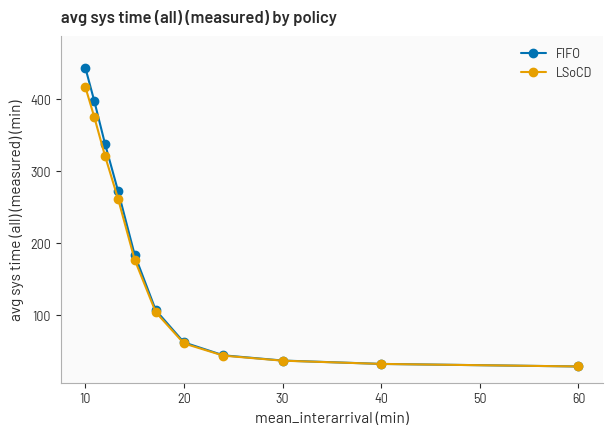

In [5]:
name = f"{METRIC} (measured)" if MEASURED else METRIC
slug = metric_slug(name)
policies = list(dict.fromkeys(results["policy"]))
colors = palette(len(policies))

fig, ax = new_figure(figsize=(7, 4.5))
for pol, color in zip(policies, colors):
    sub = results[results["policy"] == pol].sort_values(SWEPT)
    ax.plot(sub[SWEPT], sub[f"{slug}_mean"], marker="o", color=color, label=pol)
    ax.fill_between(sub[SWEPT], sub[f"{slug}_ci_low"], sub[f"{slug}_ci_high"],
                    color=color, alpha=0.0, linewidth=0)

ax.set_xlabel(SWEPT + " (min)")
#ax.set_xlim([10, 20])
ax.set_ylabel(f"{name} (min)" if "time" in name else name)
style_axes(ax, title=f"{name} by policy")
style_legend(ax)
plt.show()

## Grid: several metrics vs. the swept knob

Pick any number of metrics and get one subplot per metric, laid out in a
grid, all sharing the swept knob on the x-axis. A point gets a colored ring
around its marker wherever `GRID_PAIR`'s difference is significant at that
value of the swept knob -- see the `significant (...)` legend entry.

**The ring is a per-metric toggle.** Each entry in `METRICS_GRID` is either
a bare name (ring on, the default) or a `(name, False)` pair to turn the
ring off for just that metric -- useful when a metric's significance isn't
the point of showing it, or the ring pattern is so dense it just adds
clutter (as it was for the time metrics under heavy load, above).

Only that ONE pair is tested (matching the rest of this notebook, which
analyses one primary pair at a time -- there is no omnibus "do any of the
policies differ" test, only pairwise ones). With more than two policies in
the run, set `GRID_PAIR` explicitly to choose which comparison the rings
reflect; the other policies still plot, just without ring markers.

`SHARE_X` links every subplot's x-axis (same ticks; joint pan/zoom in an
interactive backend). `XLIM` is independent of that -- it forces the same
display range on every subplot regardless of `SHARE_X`, e.g. to zoom into
one region of the swept knob consistently across all metrics.

pair used for significance rings: 'FIFO|LSoCD'


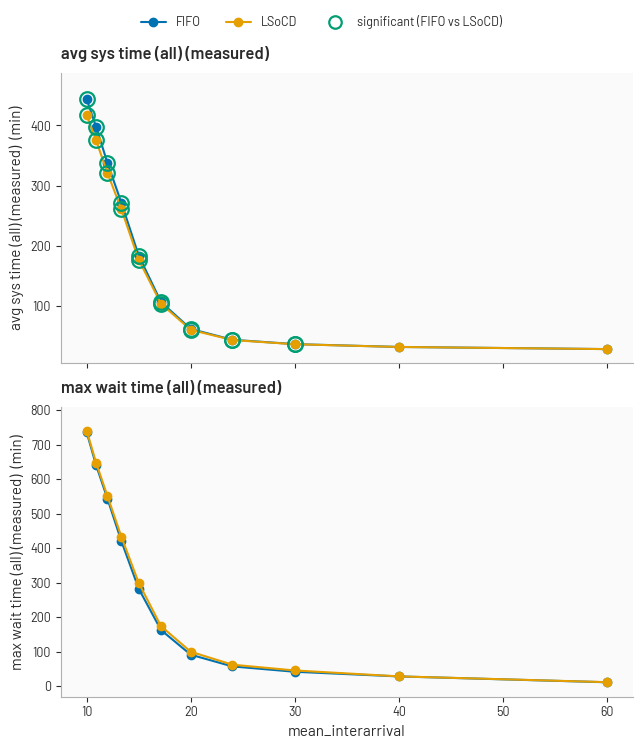

In [6]:
import math

from matplotlib.lines import Line2D

# --- what to plot -----------------------------------------------------------
# A bare name turns the significance ring ON (default); (name, False) turns
# it off for just that metric.
METRICS_GRID = [
    "avg sys time (all)",
    ("max wait time (all)", False)
    #("avg charge time", False),   # ring off -- see the markdown above
]
N_COLS = 1          # subplots per row

# --- the two toggles you asked for ------------------------------------------
SHARE_X = True       # link every subplot's x-axis (ticks, pan/zoom together)
XLIM = None          # e.g. (10, 30) to force the same x-range on every
                     # subplot regardless of SHARE_X; None leaves each auto

# --- which pair's significance gets a ring ----------------------------------
GRID_PAIR = None    # None -> first pair in `comparisons` (same rule as PAIR
                     # above); set e.g. "FIFO|LSoCD" to pick a specific one

pair = GRID_PAIR or (comparisons["pair"].iloc[0] if len(comparisons) else None)
sig_policies = set(pair.split("|")) if pair else set()
print(f"pair used for significance rings: {pair!r}")

policies = list(dict.fromkeys(results["policy"]))
colors = palette(len(policies))
sig_color = palette(3)[2]  # same "significant" ring color as the diff plot above

# Each entry is either "metric name" (ring on) or ("metric name", ring_on).
metric_labels = [e if isinstance(e, str) else e[0] for e in METRICS_GRID]
ring_on = [True if isinstance(e, str) else bool(e[1]) for e in METRICS_GRID]

names = [f"{m} (measured)" if MEASURED else m for m in metric_labels]
slugs = [metric_slug(n) for n in names]
missing = [m for m, s in zip(metric_labels, slugs) if f"{s}_mean" not in results.columns]
if missing:
    raise KeyError(f"Not in results: {missing}. Available: {metrics}")

n = len(METRICS_GRID)
ncols = min(N_COLS, n)
nrows = math.ceil(n / ncols)
fig, axes = new_figure(
    figsize=(6.5 * ncols, 3.6 * nrows), nrows=nrows, ncols=ncols,
    sharex=SHARE_X, squeeze=False,
)
axes_flat = axes.ravel()

# Did any subplot actually use the ring? Drives whether the legend gets a
# "significant" entry -- an entry for a ring nothing shows would be a lie.
any_ring_drawn = False

for i, (ax, name, slug, show_ring) in enumerate(zip(axes_flat, names, slugs, ring_on)):
    # Significant x-values for THIS metric, from the paired-comparison table.
    sig_x: set = set()
    if pair and show_ring:
        view_m = comparisons[
            (comparisons["pair"] == pair) & (comparisons["metric"] == name)
        ]
        sig_x = set(view_m.loc[view_m["significant"], SWEPT])

    for pol, color in zip(policies, colors):
        sub = results[results["policy"] == pol].sort_values(SWEPT)
        ax.plot(sub[SWEPT], sub[f"{slug}_mean"], marker="o", color=color, label=pol)
        ax.fill_between(sub[SWEPT], sub[f"{slug}_ci_low"], sub[f"{slug}_ci_high"],
                        color=color, alpha=0.0, linewidth=0)
        # Ring only the pair being tested, and only when this metric's own
        # toggle is on -- see the markdown above for both restrictions.
        if pol in sig_policies and sig_x:
            hit = sub[sub[SWEPT].isin(sig_x)]
            # ax.plot, not ax.scatter -- so this ring goes through the same
            # Line2D rendering/pixel-snapping as the dot it circles above.
            # scatter's PathCollection markers snap to the pixel grid
            # slightly differently than Line2D markers, which is what made
            # the rings look a little off-center from their dots.
            ax.plot(hit[SWEPT], hit[f"{slug}_mean"], marker="o", linestyle="none",
                    markerfacecolor="none", markeredgecolor=sig_color,
                    markeredgewidth=1.6, markersize=10.5, zorder=5)
            any_ring_drawn = any_ring_drawn or len(hit) > 0

    if XLIM is not None:
        ax.set_xlim(*XLIM)
    # With a shared x-axis, only the bottom-most subplot in each COLUMN needs
    # its own x tick labels/label -- y stays per-subplot regardless, since
    # each panel is a different metric with its own units. `i + ncols >= n`
    # is "nothing plotted directly below me", which is also correct for a
    # ragged last row (fewer metrics than nrows*ncols).
    is_col_bottom = (i + ncols) >= n
    if SHARE_X and not is_col_bottom:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel(SWEPT)
    ax.set_ylabel(f"{name}  (min)" if "time" in name else name)
    style_axes(ax, title=name)

# Hide any unused trailing axes when METRICS_GRID doesn't fill the grid.
for ax in axes_flat[n:]:
    ax.set_visible(False)

# One shared legend for the whole grid: a handle per policy, plus one for
# the significance ring -- omitted entirely if no subplot actually drew one.
handles = [Line2D([0], [0], color=c, marker="o", label=p)
          for p, c in zip(policies, colors)]
if any_ring_drawn:
    handles.append(Line2D(
        [0], [0], marker="o", linestyle="none", markerfacecolor="none",
        markeredgecolor=sig_color, markeredgewidth=1.6, markersize=9,
        label=f"significant ({pair.replace('|', ' vs ')})",
    ))
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.04),
          ncol=len(handles), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## The paired comparison: is the difference real?

This is the part a per-policy table cannot express. For each configuration
and metric, every policy pair gets the mean difference `A - B` and a
confidence interval on it, computed across paired replications.

**A CI that excludes zero means the difference is significant.** `winner`
names the policy with the lower mean (lower is better for the time metrics),
or `n.s.` when the interval straddles zero.

In [7]:
PAIR = comparisons["pair"].iloc[0]   # e.g. "FIFO|LSoCD"
print("pairs in this run:", sorted(comparisons["pair"].unique()))

# The exact metric string the comparison table is keyed on. Defined once here
# and reused by the difference plot below, so its axis label can never drift
# from the rows it actually filters -- note this is METRIC (cell 5), which is
# independent of METRICS_GRID in the grid plot above. If the two plots seem to
# disagree, check that first: they may simply be showing different metrics.
METRIC_FULL = f"{METRIC} (measured)" if MEASURED else METRIC
print("difference plot metric:", METRIC_FULL)

view = comparisons[
    (comparisons["pair"] == PAIR) & (comparisons["metric"] == METRIC_FULL)
].sort_values(SWEPT)

view[[SWEPT, "policy_a", "policy_b", "mean_a", "mean_b", "diff_mean",
      "diff_ci_low", "diff_ci_high", "significant", "winner"]].round(3)

pairs in this run: ['FIFO|LSoCD']
difference plot metric: avg sys time (all) (measured)


,mean_interarrival,policy_a,policy_b,mean_a,mean_b,diff_mean,diff_ci_low,diff_ci_high,significant,winner
340,10.000,FIFO,LSoCD,443.712,417.017,26.695,25.168,28.222,True,LSoCD
308,10.909,FIFO,LSoCD,397.395,375.085,22.310,20.378,24.242,True,LSoCD
276,12.000,FIFO,LSoCD,337.710,320.988,16.721,15.099,18.344,True,LSoCD
244,13.333,FIFO,LSoCD,271.701,260.907,10.794,9.517,12.071,True,LSoCD
212,15.000,FIFO,LSoCD,183.897,177.082,6.815,5.623,8.007,True,LSoCD
180,17.143,FIFO,LSoCD,106.713,103.935,2.779,2.054,3.503,True,LSoCD
148,20.000,FIFO,LSoCD,61.975,60.560,1.415,1.110,1.720,True,LSoCD
116,24.000,FIFO,LSoCD,44.037,43.603,0.434,0.305,0.562,True,LSoCD
84,30.000,FIFO,LSoCD,36.789,36.601,0.188,0.066,0.311,True,LSoCD
52,40.000,FIFO,LSoCD,32.106,32.082,0.023,-0.007,0.053,False,n.s.


### Difference plot

The paired difference with its confidence interval. Points whose error bar
crosses the dashed zero line are not statistically distinguishable.

**Several runs on one plot.** List them in `RUNS` and each gets its own
colour. The x-axis is normalised so runs with different pile counts line up:
see `X_NORM` below for why that is `mean_interarrival * n_piles` and not
`/ n_piles`.

'avg sys time (all) (measured)' treated as lower-is-better (set LOWER_IS_BETTER to override)


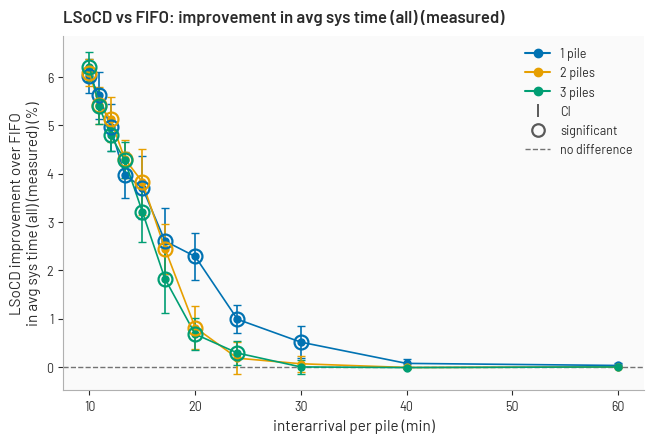

above zero -> LSoCD beats FIFO; below zero -> LSoCD is worse


In [8]:
from matplotlib.lines import Line2D

# --- which runs to overlay ---------------------------------------------------
# One colour per run. `RUNS = [RUN_NAME]` reproduces the single-run plot.
RUNS = [
    "queue_sweep_LSoCD_1pile",
    "queue_sweep_LSoCD_2pile",
    "queue_sweep_LSoCD_3pile",
]
# Optional display names; any run left out is labelled "<n> pile(s)" when the
# run has a single pile count, else by its run name.
RUN_LABELS: dict[str, str] = {}

# --- x-axis normalisation ----------------------------------------------------
# These runs are built so the load PER PILE matches across them, and the
# quantity that makes those coincide is mean_interarrival * n_piles:
#
#     arrival rate per pile = 1 / (mean_interarrival * n_piles)
#
# so equal per-pile load <=> equal mean_interarrival * n_piles. On this data:
#
#     1 pile  @ 10.000 -> 10.0     2 piles @ 5.000 -> 10.0     3 piles @ 3.333 -> 10.0
#
# i.e. every run lands on the same x-values and the curves overlay. Dividing
# instead would put them at 10.0 / 2.5 / 1.111 and they would never line up.
# Swap the `*` for a `/` here if you want the other quantity.
X_NORM = lambda df: df["mean_interarrival"] * df["n_piles"]
X_LABEL = "interarrival per pile (min)"

# --- how to express the paired difference ------------------------------------
# AS_IMPROVEMENT reframes the chart around a BASELINE policy: the value
# becomes how much better the OTHER policy is, so positive always means
# "the other policy wins" regardless of whether the metric is one you want
# high or low. With it off you get the raw signed difference instead.
#
# AS_PERCENT divides by the baseline's own mean. Both rescalings are by a
# positive per-point constant (plus, for improvement, possibly a sign flip),
# so the CI travels with the centre and which points are significant never
# changes -- only the units and the orientation do.
AS_IMPROVEMENT = True    # positive = the non-baseline policy is better
AS_PERCENT = True        # True -> % of the baseline's own mean
BASELINE = None          # None -> PAIR's first policy; or name one explicitly
LOWER_IS_BETTER = None   # None -> infer from the metric name; or force True/False

# Which direction counts as "better" for THIS metric. Only matters when
# AS_IMPROVEMENT is on, and it is printed so a wrong guess is visible --
# util_rho in particular is genuinely ambiguous, so set it explicitly there.
HIGHER_IS_BETTER_METRICS = ("finished EVs", "total energy delivered")
if LOWER_IS_BETTER is None:
    lower_better = not METRIC_FULL.startswith(HIGHER_IS_BETTER_METRICS)
else:
    lower_better = bool(LOWER_IS_BETTER)


def _difference_series(d, pair):
    """One run's rows -> (x, centre, err_low, err_high, significant, labels).

    Applies the same sign/percent rescaling as the single-run version, using
    THIS run's own pair for which column is the baseline's mean.
    """
    a, b = pair.split("|")
    baseline = BASELINE or a
    if baseline not in (a, b):
        raise ValueError(f"BASELINE must be one of {(a, b)}, got {baseline!r}")
    other = b if baseline == a else a

    # comparisons stores diff_mean as (a - b). Flip it when b is the baseline
    # so the quantity is always (baseline - other); flip again for a
    # higher-is-better metric so that positive still reads as "other wins".
    sign = -1.0 if baseline == b else 1.0
    if AS_IMPROVEMENT and not lower_better:
        sign = -sign
    base_mean = d["mean_a"] if baseline == a else d["mean_b"]

    if AS_PERCENT:
        good = base_mean.abs() > 1e-12
        if not good.all():
            print(f"  note: dropped {int((~good).sum())} point(s) where "
                  f"{baseline}'s mean is 0 -- a percentage of zero is undefined")
            d, base_mean = d[good], base_mean[good]
        scale = sign * 100.0 / base_mean
    else:
        scale = sign

    centre = d["diff_mean"] * scale
    lo = d["diff_ci_low"] * scale
    hi = d["diff_ci_high"] * scale
    # Guard the ordering: the sign flip above (and a negative baseline mean)
    # would otherwise swap the bounds, and matplotlib rejects negative yerr.
    lo_s, hi_s = lo.where(lo <= hi, hi), hi.where(lo <= hi, lo)
    return (
        X_NORM(d), centre, centre - lo_s, hi_s - centre,
        d["significant"].astype(bool), baseline, other,
    )


unit = "%" if AS_PERCENT else ("min" if "time" in METRIC_FULL else "")
fig, ax = new_figure(figsize=(7.5, 4.6))
colors = palette(len(RUNS))
handles: list = []
baselines, others = set(), set()

for run, color in zip(RUNS, colors):
    comp = load_results(run, "comparisons")
    pair = PAIR if PAIR in set(comp["pair"]) else comp["pair"].iloc[0]
    if pair != PAIR:
        print(f"  {run}: PAIR {PAIR!r} not in this run, using {pair!r}")

    d = comp[(comp["pair"] == pair) & (comp["metric"] == METRIC_FULL)]
    if d.empty:
        print(f"  {run}: no rows for {METRIC_FULL!r} / {pair!r} -- skipped")
        continue
    d = d.sort_values("mean_interarrival")

    x, centre, err_low, err_high, sig, baseline, other = _difference_series(d, pair)
    baselines.add(baseline)
    others.add(other)

    n_piles = sorted(d["n_piles"].unique())
    label = RUN_LABELS.get(
        run,
        f"{n_piles[0]} pile{'s' if n_piles[0] != 1 else ''}"
        if len(n_piles) == 1 else run,
    )

    ax.errorbar(x, centre, yerr=[err_low, err_high], fmt="o-", capsize=3,
                color=color, markersize=5, linewidth=1.2, zorder=3)
    # Ring the significant points in the SERIES' own colour, so with several
    # runs overlaid it stays obvious which series a ring belongs to. Drawn
    # with ax.plot (not ax.scatter) so the ring goes through the same Line2D
    # pixel-snapping as the errorbar's marker and stays concentric with it.
    ax.plot(x[sig], centre[sig], marker="o", linestyle="none",
            markerfacecolor="none", markeredgecolor=color, markeredgewidth=1.6,
            markersize=10.0, zorder=4)
    handles.append(Line2D([0], [0], marker="o", color=color, label=label))

if len(baselines) > 1 or len(others) > 1:
    print(f"  WARNING: runs disagree on the policy pair "
          f"(baselines={sorted(baselines)}, others={sorted(others)}) -- "
          "the series are not directly comparable")

baseline = next(iter(baselines), "baseline")
other = next(iter(others), "other")
ax.axhline(0.0, linestyle="--", linewidth=1.0, color="0.45", zorder=1)

if AS_IMPROVEMENT:
    y_label = f"{other} improvement over {baseline}\nin {METRIC_FULL}"
    title = f"{other} vs {baseline}: improvement in {METRIC_FULL}"
    print(f"'{METRIC_FULL}' treated as {'lower' if lower_better else 'higher'}"
          "-is-better (set LOWER_IS_BETTER to override)")
else:
    y_label = f"difference in {METRIC_FULL}"
    title = f"{baseline} vs {other}: paired difference in {METRIC_FULL}"

ax.set_xlabel(X_LABEL)
ax.set_ylabel(y_label + (f" ({unit})" if unit else ""))
style_axes(ax, title=title)

# Legend: one entry per run, then the shared annotations. The CI handle is a
# real (but data-less) errorbar so matplotlib draws it as the same whisker+cap
# icon the real bars use, without adding any point to the axes. The ring and
# CI proxies are drawn neutral since they apply to every series, each of which
# renders them in its own colour.
ci_handle = ax.errorbar([], [], yerr=[], fmt="none", ecolor="0.35",
                        elinewidth=1.4, capsize=3, capthick=1.4, label="CI")
sig_handle = Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="none",
                    markeredgecolor="0.35", markeredgewidth=1.6, markersize=9,
                    label="significant")
zero_handle = Line2D([0], [0], linestyle="--", linewidth=1.0, color="0.45",
                     label="no difference")
style_legend(ax, handles=handles + [ci_handle, sig_handle, zero_handle])
plt.show()

if AS_IMPROVEMENT:
    print(f"above zero -> {other} beats {baseline}; below zero -> {other} is worse")
else:
    print(f"above zero -> {other} is lower (better); below zero -> {baseline} is lower")

## Who won what, at a glance

`sign` is `-1` when the first policy of the pair is lower, `+1` when the
second is, `0` when the difference is not significant. Scanning a whole
sweep this way shows quickly whether one policy dominates or whether the
winner depends on the operating point.

In [ ]:
signs = comparisons.pivot_table(
    index=[SWEPT, "pair"], columns="metric", values="sign", sort=False
)
# Keep the time metrics, which are the ones with a clear better direction.
keep = [c for c in signs.columns if "time" in c and "(measured)" not in c]
signs[keep].astype(int)

,metric,avg wait time,max wait time,avg charge time,avg sys time
mean_interarrival,pair,,,,
60.000000,FIFO|LSoCD,0,0,0,0
40.000000,FIFO|LSoCD,1,0,0,1
30.000000,FIFO|LSoCD,1,-1,0,1
24.000000,FIFO|LSoCD,1,-1,0,1
20.000000,FIFO|LSoCD,1,-1,0,1
17.142857,FIFO|LSoCD,1,-1,1,1
15.000000,FIFO|LSoCD,1,-1,1,1
13.333333,FIFO|LSoCD,1,-1,1,1
12.000000,FIFO|LSoCD,1,-1,1,1


## Raw replications

`replications.csv` holds every episode's own metric values, so anything
above can be recomputed at a different confidence level, or with a different
test, without re-simulating. Join back to configs on `config_id`.

In [ ]:
per_seed = reps.pivot_table(
    index=["config_id", "seed"], columns="policy", values=METRIC
)
print(f"spread of {METRIC!r} across replications, config 0:")
per_seed.loc[0].describe().round(2)

spread of 'avg sys time' across replications, config 0:


policy,FIFO,LSoCD
count,30.00,30.00
mean,29.17,29.16
std,2.13,2.12
min,24.94,24.94
25%,27.90,27.90
50%,29.32,29.32
75%,30.81,30.81
max,32.42,32.42


## Notes

- **Common random numbers matter.** All policies in a config share the seed
  sequence, so `compare_policies` pairs them per replication. The paired CI
  is much tighter than the per-policy CIs suggest -- overlapping bands in
  the first plot do *not* imply "no difference".
- **`max_wait_used`** records what each policy's queue-wait override actually
  was. With `max_wait_from="FIFO"` the reference policy runs unconstrained
  and the others get its observed mean max wait times `max_wait_factor`, so
  the value is derived from the run rather than fixed by the config.
- **Lower is better** for the time metrics (`avg sys time`, `avg wait time`,
  `max wait time`, `avg charge time`) and for `dropped EVs`; higher is better
  for `finished EVs` and `total energy delivered (kWh)`. The `sign` column
  only encodes which mean is *lower*, so interpret it accordingly.
- This sweep is pure simulation. For how far a policy sits from the true
  optimum, see the objective sweep and `objective_sweep_results.ipynb`.